In [7]:
%load_ext autoreload
%reload_ext autoreload

%autoreload 2
%matplotlib inline
import tensorflow
import pybedtools
import pyBigWig
from tensorflow.compat.v1.keras.backend import get_session
tensorflow.compat.v1.disable_v2_behavior()
import math
import kerasAC 
from scipy.special import softmax,expit
from kerasAC.interpret.deepshap import * 
from kerasAC.interpret.profile_shap import * 
from kerasAC.vis import * 
from kerasAC.helpers.transform_bpnet_io import * 
from kerasAC.util import * 
import pandas as pd
from statsmodels.distributions.empirical_distribution import ECDF
## for plotting 

import matplotlib 
from matplotlib import pyplot as plt
plt.rcParams["figure.figsize"]=10,5
plt.rcParams['axes.xmargin'] = 0

font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : 10}

matplotlib.rc('font', **font)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
#load the model! 
from keras.models import load_model
from keras.utils.generic_utils import get_custom_objects
from kerasAC.metrics import * 
from kerasAC.custom_losses import * 
custom_objects={"recall":recall,
                    "sensitivity":recall,
                    "specificity":specificity,
                    "fpr":fpr,
                    "fnr":fnr,
                    "precision":precision,
                    "f1":f1,
                    "ambig_binary_crossentropy":ambig_binary_crossentropy,
                    "ambig_mean_absolute_error":ambig_mean_absolute_error,
                    "ambig_mean_squared_error":ambig_mean_squared_error,
                    "MultichannelMultinomialNLL":MultichannelMultinomialNLL}
get_custom_objects().update(custom_objects)
model=load_model("/srv/scratch/annashch/chrombpnet/k562_dnase/bpnet/with_bias_unplugged/k562.dnase.with.bias.unplugged.0.hdf5")
pbw=pyBigWig.open("/oak/stanford/groups/akundaje/projects/atlas/dnase_processed/dnase/09ce5f39-5360-411b-88dd-b86f4a1286a7/call-bowtie2/shard-0/execution/ENCSR000EOT.merged.bam.bpnet.unstranded.bw",'r')

In [9]:
#create the explainers 
model_wrapper=(model.input, model.outputs[1])
count_explainer=shap.DeepExplainer(model_wrapper,
                                   data=create_background_atac,
                                   combine_mult_and_diffref=combine_mult_and_diffref_1d)


In [10]:
prof_output = model.output[0]                                                                                                      
logits = prof_output - tf.reduce_mean(prof_output, axis=1, keepdims=True)
logits_stopgrad=tf.stop_gradient(logits)
probs=tf.nn.softmax(logits_stopgrad,axis=1)
logits_weighted=logits*probs 
prof_sum=tf.reduce_sum(logits_weighted,axis=(1,2))
prof_explainer=shap.DeepExplainer(model=(model.input,prof_sum),
                                  data=create_background_atac,
                                  combine_mult_and_diffref=combine_mult_and_diffref_1d)


In [15]:
from scipy.special import softmax 
def make_plot(label_counts_track,
              pred_count_track,
              pred_count_val,
              deepshap_prof,
              deepshap_count,
              single_bp_ism_profile_track,
              single_bp_ism_count_track,
              single_bp_ism_mat_observed,
              title,
              xmin=0,
              xmax=2114): 
    plt.rcParams["figure.figsize"]=15,25
    f,axes=plt.subplots(7, 1,sharex='row')
    plt.set_cmap('RdBu')
    
    #labels count track 
    axes[0].plot(label_counts_track)  
    axes[0].set_title("Label Counts")
    
    #alt & ref predicted count tracks 
    axes[1].plot(pred_count_track,label='pred counts per base',color='b')
    axes[1].set_title("Counts Pred:"+str(pred_count_val))
    axes[1].legend() 
    
    #plot DeepSHAP tracks for profile & counts, for ref & alt alleles 
    axes[2]=plot_bases_on_ax(deepshap_prof,axes[2],show_ticks=False)
    axes[2].set_title('DeepSHAP Profile ')
    axes[2].set_ylim(-0.05,0.05)
    
    axes[3]=plot_bases_on_ax(deepshap_count,axes[3],show_ticks=False)
    axes[3].set_title('DeepSHAP Count')
    axes[3].set_ylim(-0.05,0.05)

    axes[4]=plot_bases_on_ax(single_bp_ism_profile_track,axes[4],show_ticks=False)
    axes[4].set_title("ISM Profile, single bp")
         
    axes[5]=plot_bases_on_ax(single_bp_ism_count_track,axes[5],show_ticks=False)
    axes[5].set_title("ISM Count, single bp")
    
    
    for i in range(6): 
        axes[i].set_xlim(xmin,xmax)
        axes[i].set_xticks(list(range(xmin, xmax, 100)))  
        
    extent = [0, single_bp_ism_mat_observed.shape[0], 0, single_bp_ism_mat_observed.shape[1]]
    #abs_highest=max([abs(ymin),abs(ymax)])
    hmap1=axes[6].imshow(single_bp_ism_mat_observed.T,
                        extent=extent,
                        vmin=-0.5,
                        vmax=0.5, 
                        interpolation='nearest',aspect='auto')
    axes[6].set_title("ISM matrix, single bp, observed allele projected")
    plt.suptitle(title)
    plt.tight_layout()
    plt.colorbar(hmap1,ax=axes[6],orientation='horizontal')
    plt.subplots_adjust(hspace=0.4)
    plt.savefig(title.replace('/',':')+'.png',format='png',dpi=300)
    #plt.show()

In [16]:
import pysam 
ref=pysam.FastaFile("/mnt/data/GRCh38_no_alt_analysis_set_GCA_000001405.15.fasta")

In [17]:
def get_deepshap(prof_explainer,count_explainer,seq_onehot): 
    profile_explanations=prof_explainer.shap_values(seq_onehot)*seq_onehot
    count_explanations=np.squeeze(count_explainer.shap_values(seq_onehot)[0])*seq_onehot  
    return profile_explanations, count_explanations

In [18]:
from scipy.special import softmax
def get_preds(model,seq_onehot):
    preds=model.predict(seq_onehot)
    prof=preds[0]
    probs=np.squeeze(softmax(prof,axis=1))
    count=np.squeeze(preds[1])  
    count_track=probs*count 
    return prof,count,probs,count_track

In [19]:
# 2114, 1000, 4
#get observed ism, sum by pos & neg and take the one w/ larger magnitude 
def get_observed_ism_from_mat(profile,seq):
    print(profile.shape)
    print(seq.shape)
    pos_mask=np.zeros(profile.shape)
    pos_mask[profile>0]=1
    neg_mask=np.zeros(profile.shape)
    neg_mask[profile<0]=1
    
    pos_sum=np.sum(profile*pos_mask,axis=1)
    neg_sum=np.sum(profile*neg_mask,axis=1)
    print(pos_sum.shape)
    
    pos_sum_mask=np.zeros(pos_sum.shape)
    pos_sum_mask[pos_sum>abs(neg_sum)]=1
    neg_sum_mask=np.zeros(neg_sum.shape)
    neg_sum_mask[neg_sum<0]=1

    profile_summed_ism=pos_sum*pos_sum_mask+neg_sum*neg_sum_mask
    
    profile_summed_scaled=profile_summed_ism*seq
    
    #final_profile_vals=profile_summed_scaled.sum(axis=1)
    #return final_profile_vals
    return profile_summed_scaled

In [20]:
def get_ism_single_bp(model,seq,prof_pred,count_pred):
    #expand default preds to match dimensions for ISM
    default_prof_expanded=np.zeros((len(seq),1000,4))
    default_count_expanded=np.zeros((len(seq),4))
    for j in range(4):
        for i in range(len(seq)):
            default_prof_expanded[i,:,j]=prof_pred
            default_count_expanded[i,j]=count_pred
    #create placeholders for ISM predictions
    ind_to_base={0:'A',1:'C',2:'G',3:'T'}
    placeholder_prof=np.zeros((len(seq),1000,4))
    placeholder_count=np.zeros((len(seq),4))
    for j in range(4):
        cur_allele_seqs=[]
        for i in range(len(seq)):
            cur_allele_seqs.append(seq[0:i]+ind_to_base[j]+seq[i+1::])
        #get predictions for this allele
        cur_allele_preds=model.predict([one_hot_encode(cur_allele_seqs)])
        cur_allele_prof=np.squeeze(cur_allele_preds[0])
        cur_allele_count=np.squeeze(cur_allele_preds[1])
        placeholder_prof[:,:,j]=cur_allele_prof
        placeholder_count[:,j]=cur_allele_count

    #subtract the WT, average across base axis
    placeholder_prof_normed=placeholder_prof-default_prof_expanded
    placeholder_count_normed=placeholder_count-default_count_expanded

    placeholder_prof_normed=placeholder_prof_normed-np.expand_dims(np.mean(placeholder_prof_normed,axis=2),axis=2)
    placeholder_count_normed=placeholder_count_normed-np.expand_dims(np.mean(placeholder_count_normed,axis=1),axis=1)

    #DO NOT SCALE BY SEQUENCE SO WE CAN HAVE A FLEXIBLE PRECOMPUTED ISM DATASET FOR SUBSEQUENT ANALYSIS
    #seq_onehot=one_hot_encode([seq])

    #ism_profile_track=np.sum(np.abs(placeholder_prof_normed),axis=1)*seq_onehot
    #ism_count_track=placeholder_count_normed*seq_onehot

    #ism heatmap:
    #ism_mat_observed=np.sum(np.expand_dims(np.squeeze(seq_onehot),axis=1)*placeholder_prof_normed,axis=2)
    #return ism_profile_track, ism_count_track, ism_mat_observed
    return placeholder_prof_normed, placeholder_count_normed

In [22]:
regions=pd.read_csv("regions_for_anna_03_21_2021.tsv",header=None,sep='\t')

Instructions for updating:
This property should not be used in TensorFlow 2.0, as updates are applied automatically.
(2114, 1000, 4)
(2114, 4)
(2114, 4)


findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.
findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.


(2114, 1000, 4)
(2114, 4)
(2114, 4)
(2114, 1000, 4)
(2114, 4)
(2114, 4)
(2114, 1000, 4)
(2114, 4)
(2114, 4)
(2114, 1000, 4)
(2114, 4)
(2114, 4)
(2114, 1000, 4)
(2114, 4)
(2114, 4)
(2114, 1000, 4)
(2114, 4)
(2114, 4)
(2114, 1000, 4)
(2114, 4)
(2114, 4)
(2114, 1000, 4)
(2114, 4)
(2114, 4)
(2114, 1000, 4)
(2114, 4)
(2114, 4)
(2114, 1000, 4)
(2114, 4)
(2114, 4)
(2114, 1000, 4)
(2114, 4)
(2114, 4)


KeyboardInterrupt: 

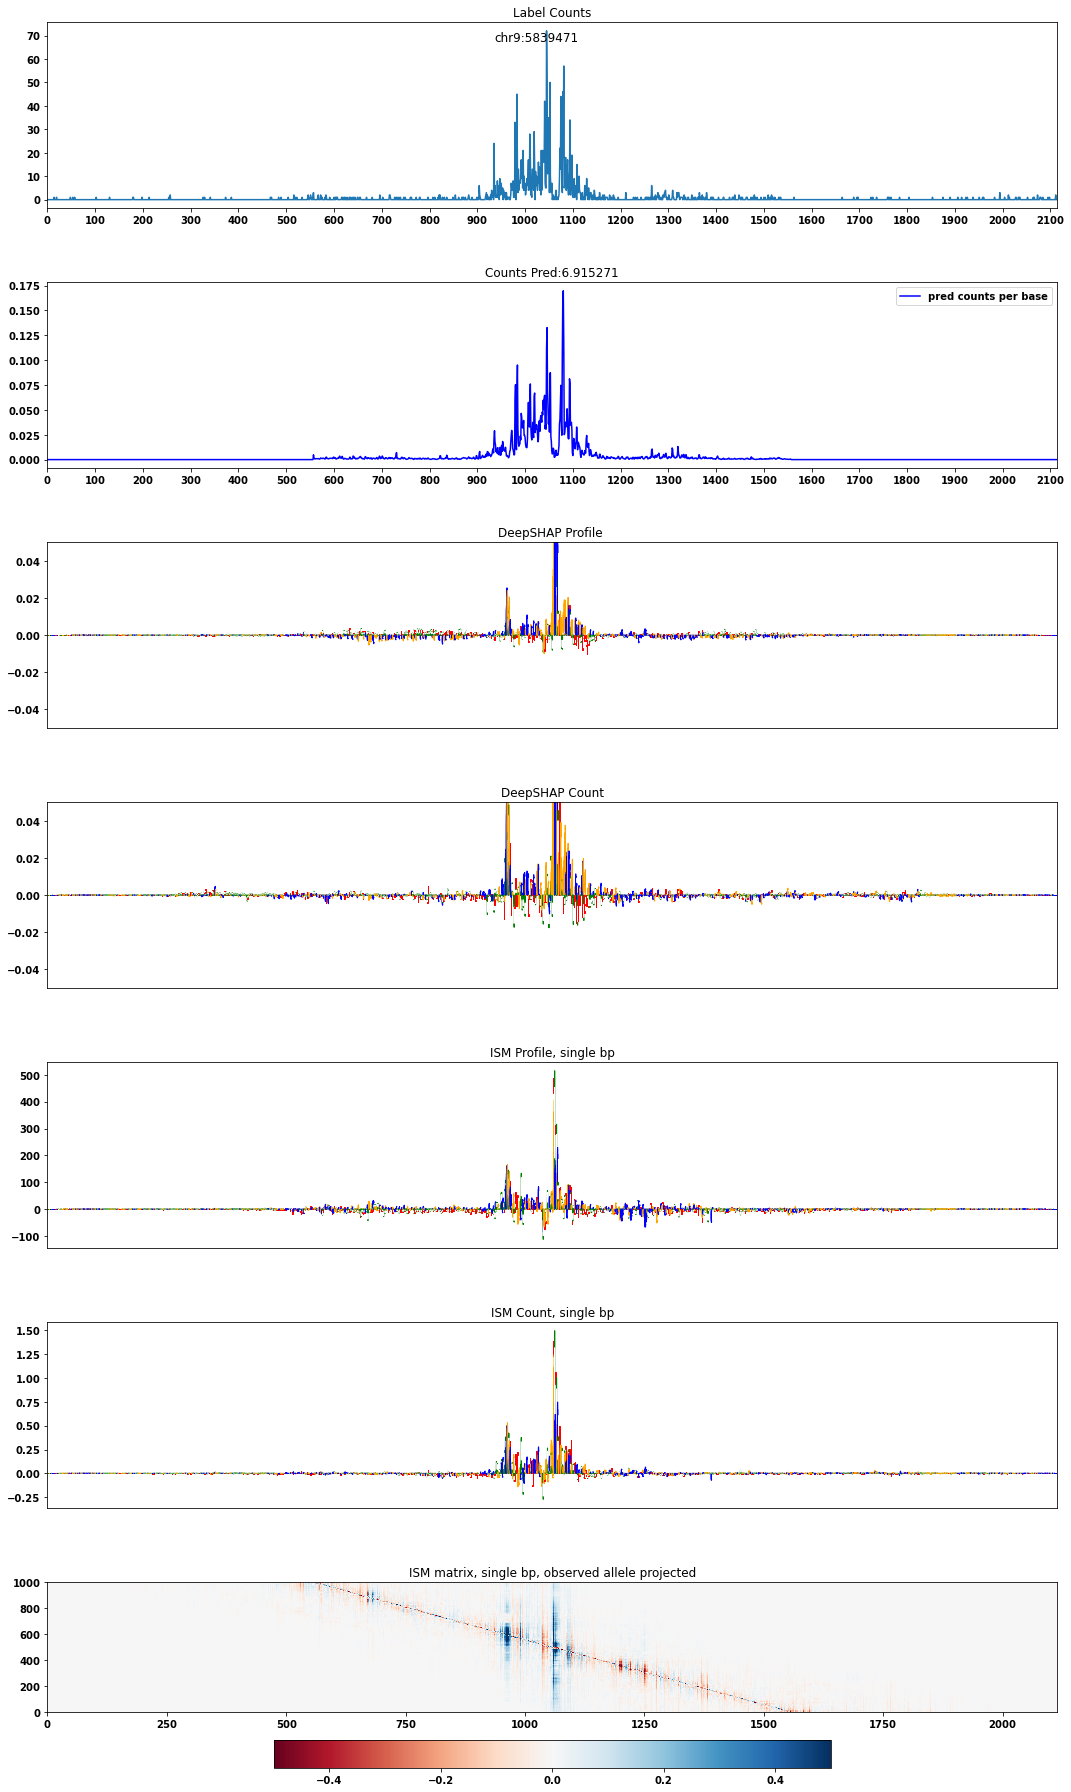

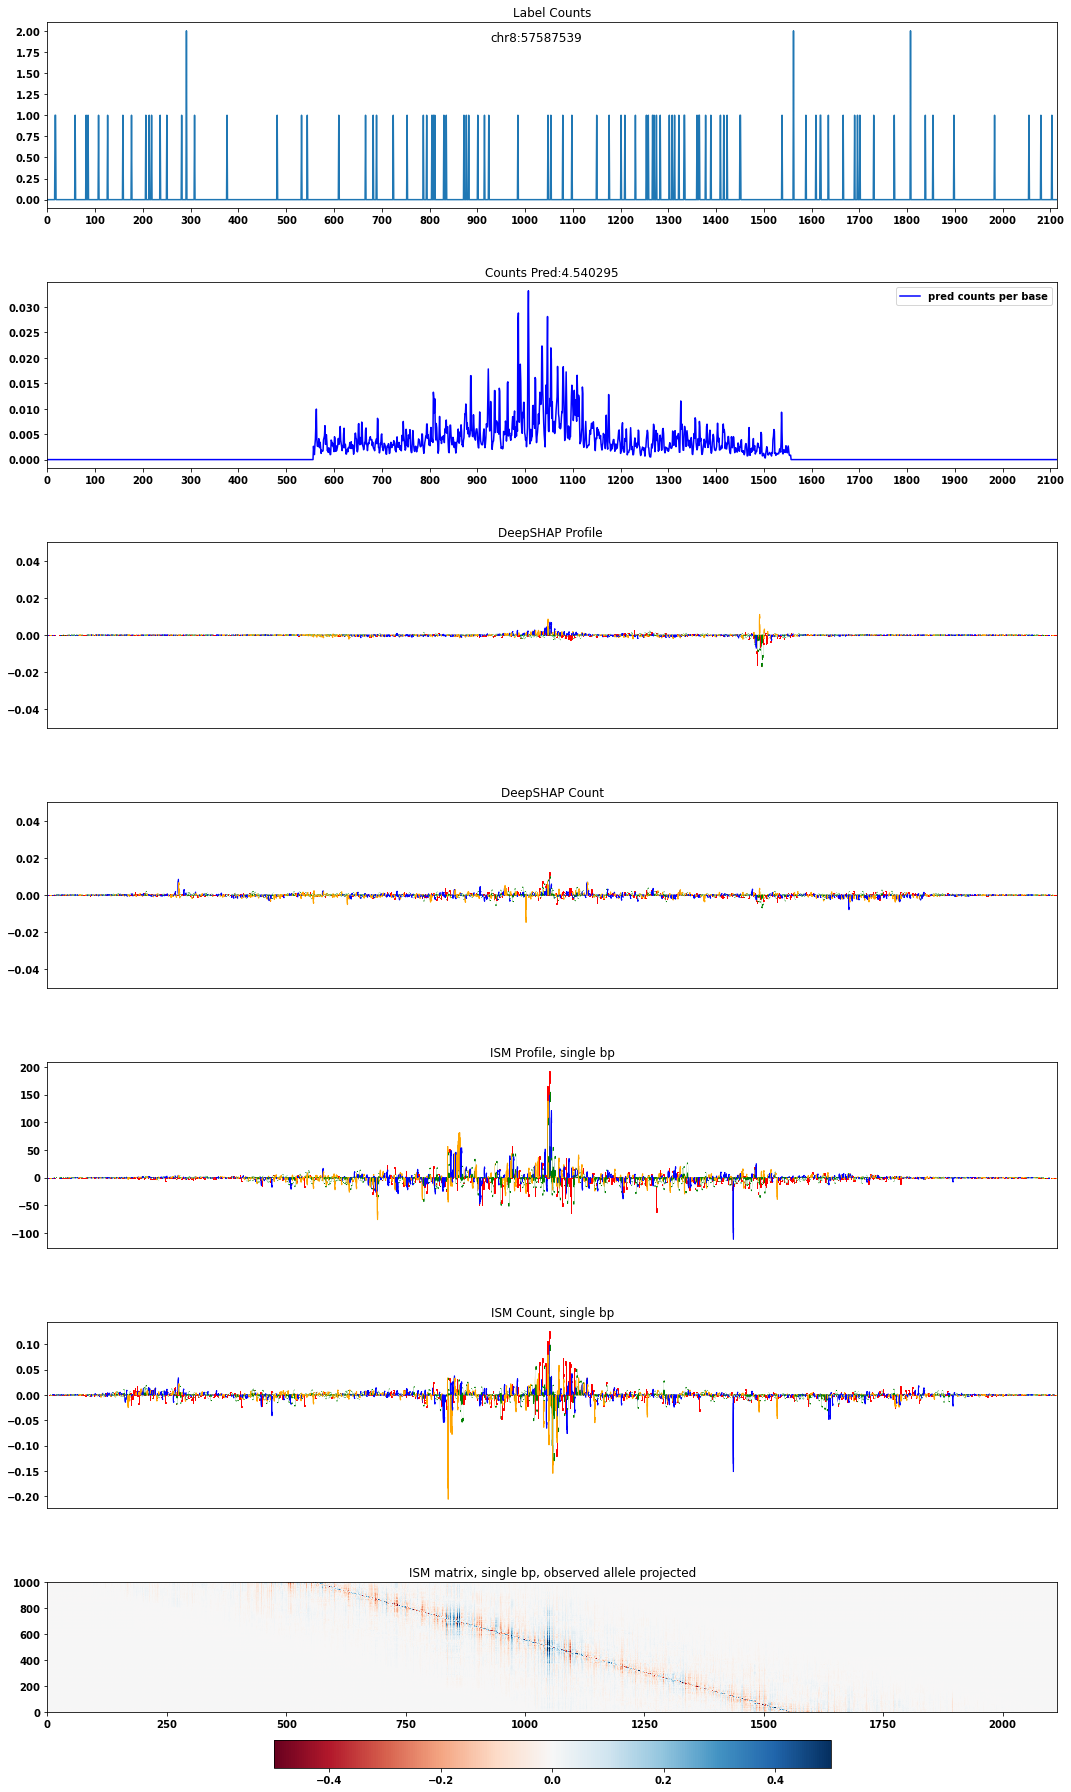

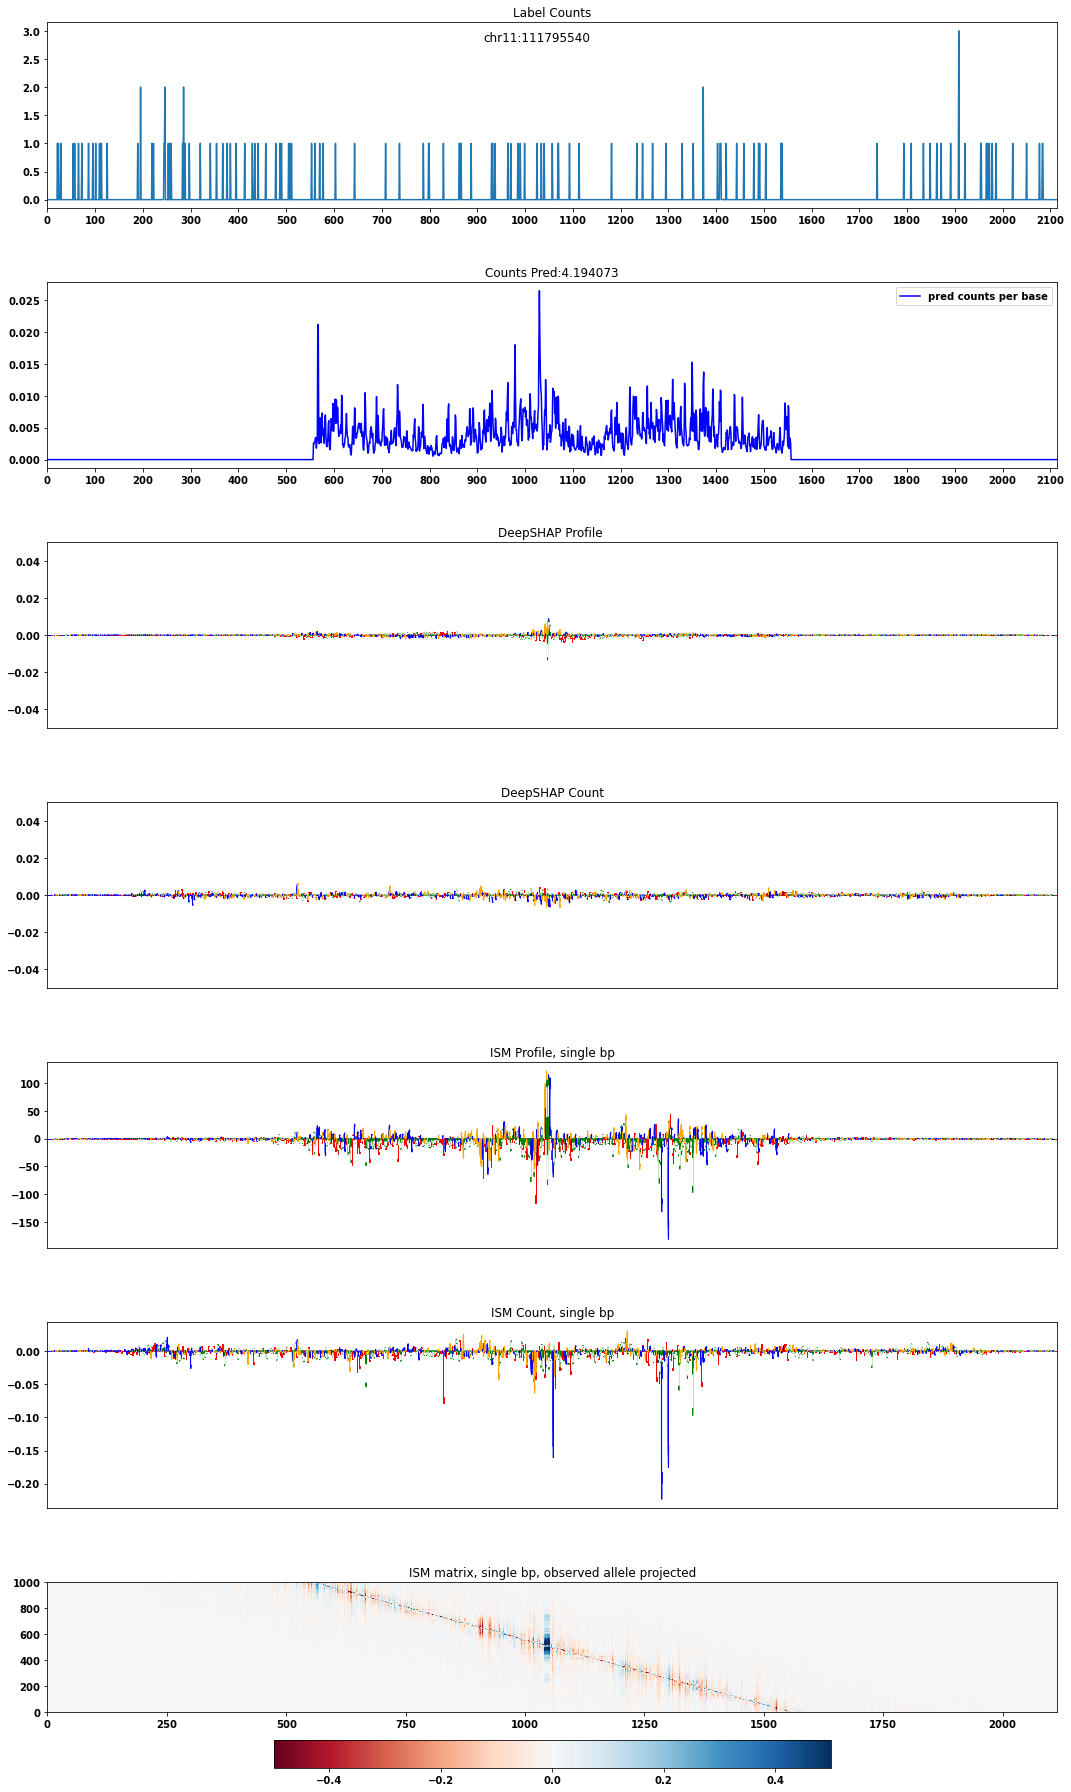

In [ ]:
model_outputs={}
flank=1057
for index,row in regions.iterrows(): 
    chrom=row[0]
    start_pos=row[1]
    end_pos=row[2]
    summit=start_pos+row[9]
    start_pos=summit-flank 
    end_pos=summit+flank 

    #get the reference and alternate one-hot-encoded sequences 
    seq=ref.fetch(chrom,summit-flank,summit+flank)
    onehot=one_hot_encode([seq])

    #get the bigwig labels 
    labels=np.nan_to_num(pbw.values(chrom,summit-flank,summit+flank))

    #prediction 
    prof_ref,count_ref,probs_ref,count_track_ref=get_preds(model,onehot)

    #get deepSHAP scores  
    profile_explanations, count_explanations=get_deepshap(prof_explainer, count_explainer, onehot)

    #get ISM scores 
    single_bp_ism_profile_track,single_bp_ism_count_track= get_ism_single_bp(model,seq,np.squeeze(prof_ref),np.squeeze(count_ref))
    single_bp_ism_profile_track_adjusted=get_observed_ism_from_mat(single_bp_ism_profile_track,np.squeeze(onehot))
    single_bp_ism_count_track_adjusted=single_bp_ism_count_track*onehot
    mat=np.sum(np.expand_dims(np.squeeze(onehot),axis=1)*single_bp_ism_profile_track,axis=2) 

    #plot to sanity check 
    make_plot(labels,
              np.concatenate((np.zeros((557,1)),np.expand_dims(count_track_ref,axis=1),np.zeros((557,1)))),
              count_ref,
              profile_explanations,
              count_explanations,
              single_bp_ism_profile_track_adjusted,
              single_bp_ism_count_track_adjusted,
              mat,
              title='k562:'+':'.join([str(chrom),str(summit)]),
              xmin=0,
              xmax=2114)
    model_outputs[(chrom,start_pos,end_pos,summit)]={'count_track_label':labels,
                                                     'count_track_prediction':np.concatenate((np.zeros((557,1)),np.expand_dims(count_track_ref,axis=1),np.zeros((557,1)))),
                                                     'count_prediction':count_ref,
                                                     'profile_deepSHAP':profile_explanations,
                                                     'count_deepSHAP':count_explanations,
                                                     'profile_ISM':single_bp_ism_profile_track_adjusted,
                                                     'count_ISM':single_bp_ism_count_track_adjusted,
                                                     'heatmap_ISM':mat}
import pickle 
pickle.dump( model_outputs, open( "k562.Vir.regions.p", "wb" ) )

1057.0